In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Titanic_EDA_Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Johnson, Miss. Anna",male,60.2,0,1,STON/O2 487649,13.1998,NaN,S
1,2,1,3,"Williams, Mrs. Mary",female,21.5,1,1,STON/O2 75442,9.6025,NaN,S
2,3,1,2,"Brown, Miss. Elizabeth",female,40.4,0,0,STON/O2 961750,22.0966,NaN,S
3,4,0,3,"Davis, Mrs. Margaret",male,NaN,0,0,PC 580886,12.0658,NaN,S
4,5,0,1,"Wilson, Miss. Emily",male,48.2,0,0,SOTON 128309,95.4824,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        189 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.257015,2.308642,30.668627,0.399551,0.408530,32.329821
std,257.353842,0.437233,0.845426,13.683320,0.790221,0.852818,34.419578
min,1.000000,0.000000,1.000000,0.400000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,1.500000,21.425000,0.000000,0.000000,11.184000
50%,446.000000,0.000000,3.000000,30.300000,0.000000,0.000000,17.281700
75%,668.500000,1.000000,3.000000,39.575000,1.000000,0.000000,37.151450
max,891.000000,1.000000,3.000000,74.700000,8.000000,5.000000,188.529600


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          702
Embarked         2
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df["Survived"].value_counts()

Survived
0    662
1    229
Name: count, dtype: int64

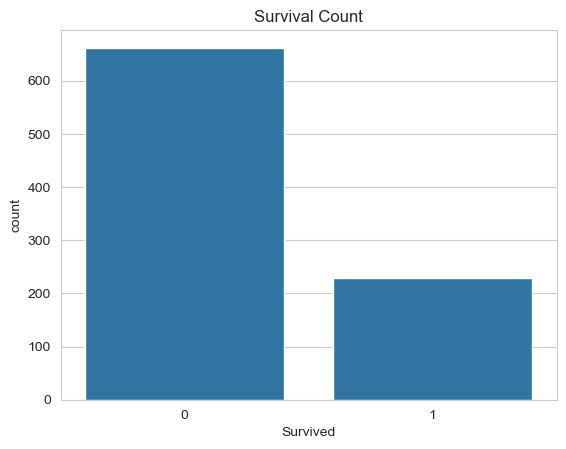

In [8]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

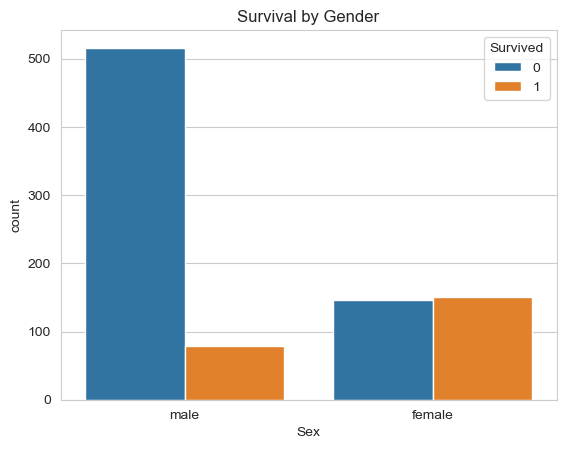

In [9]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

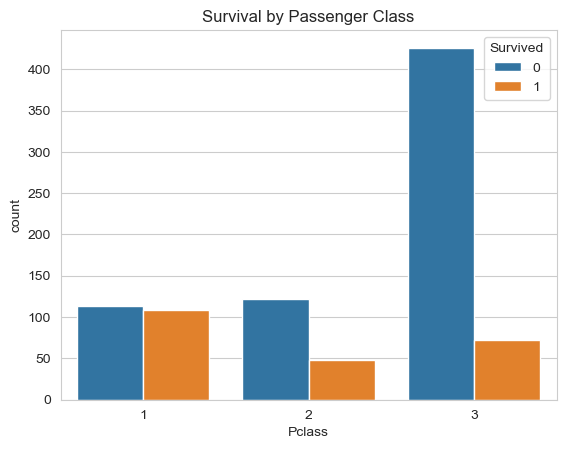

In [10]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

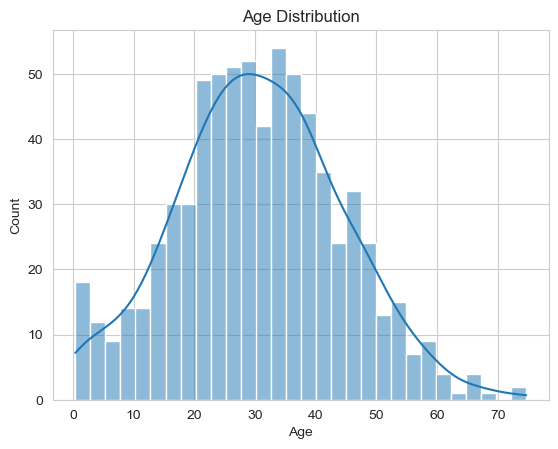

In [11]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

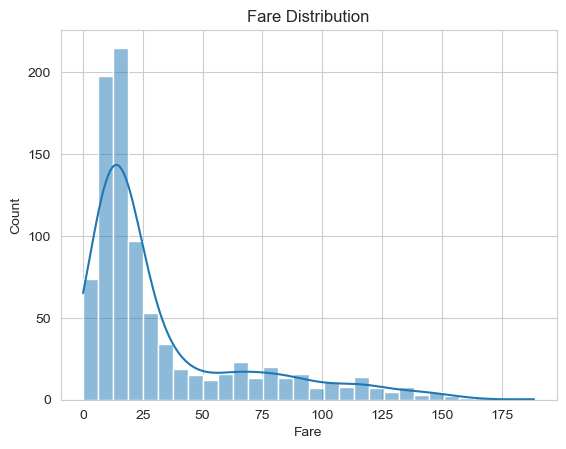

In [12]:
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

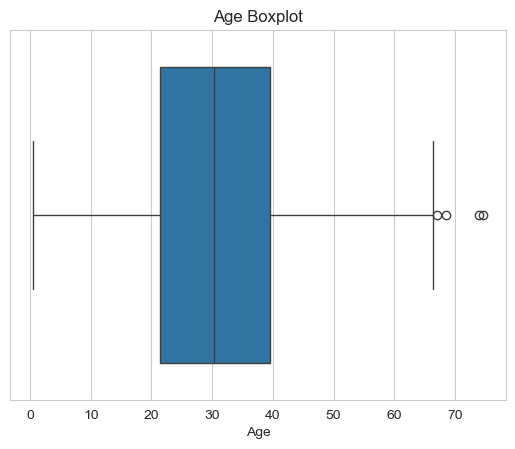

In [13]:
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

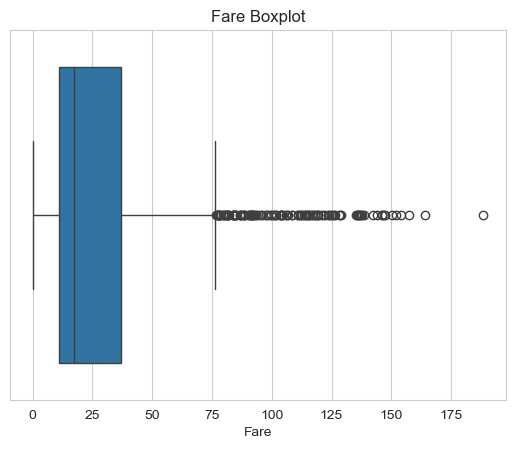

In [14]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

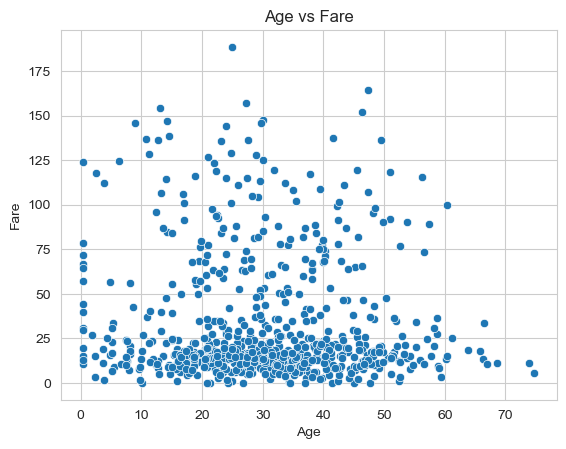

In [15]:
sns.scatterplot(x="Age", y="Fare", data=df)
plt.title("Age vs Fare")
plt.show()

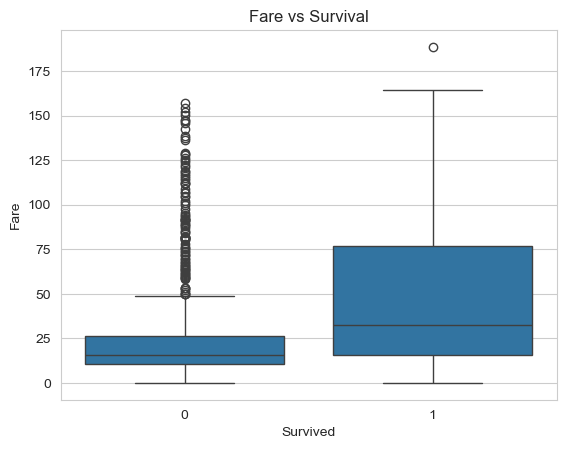

In [16]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

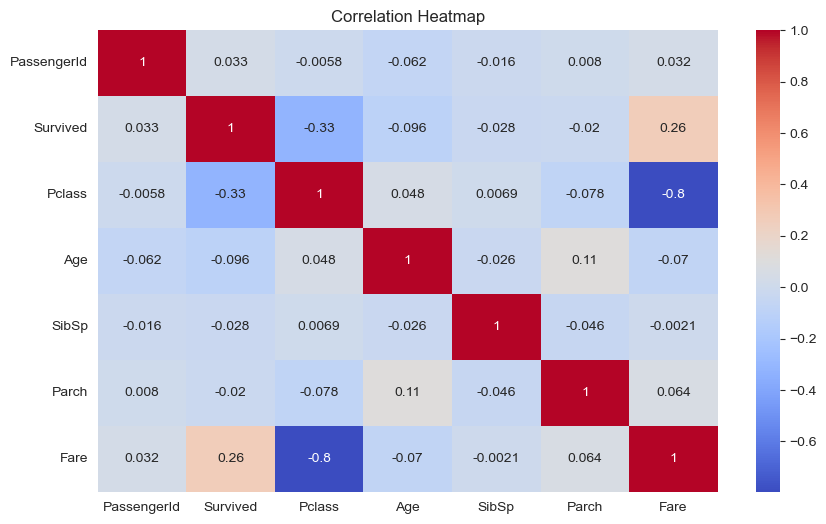

In [17]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

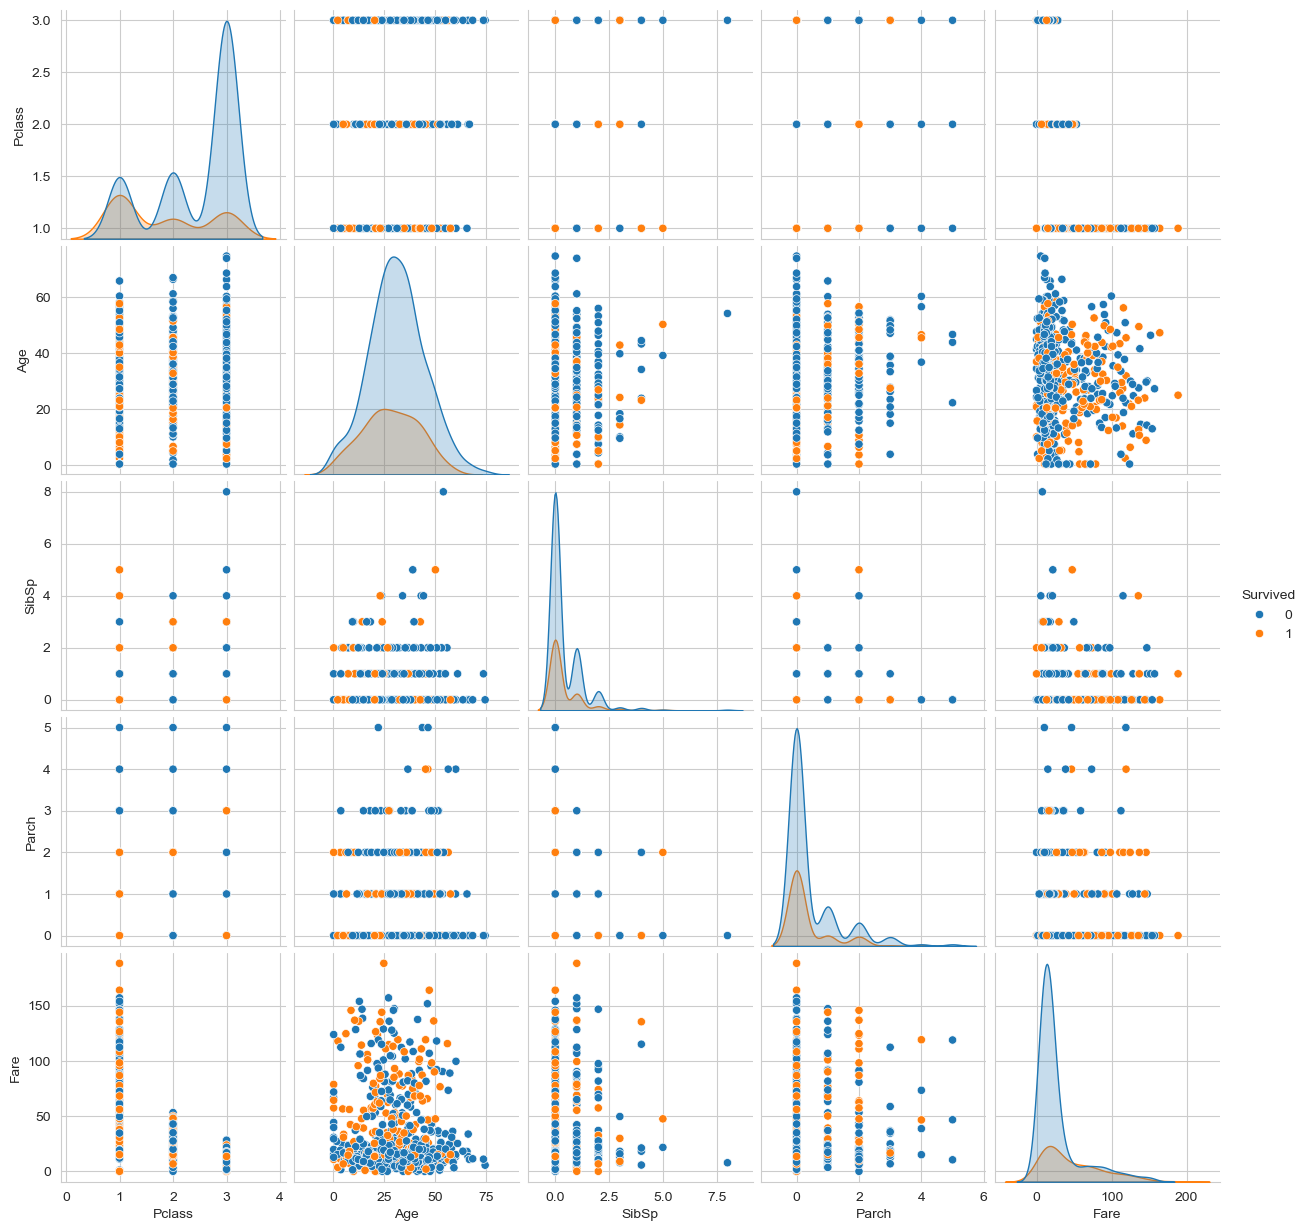

In [18]:
sns.pairplot(df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].dropna(),
             hue="Survived")
plt.show()

In [19]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [20]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [21]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          702
Embarked         0
dtype: int64

In [22]:
df["Survived"].value_counts(normalize=True) * 100

Survived
0    74.298541
1    25.701459
Name: proportion, dtype: float64

In [23]:
df.groupby("Sex")["Survived"].mean() * 100

Sex
female    50.675676
male      13.277311
Name: Survived, dtype: float64

In [24]:
df.groupby("Pclass")["Survived"].mean() * 100

Pclass
1    48.878924
2    28.235294
3    14.457831
Name: Survived, dtype: float64

In [ ]:
## Final EDA Findings

1. The Titanic dataset contains 891 passenger records and 12 columns.
2. Missing values were found mainly in Age and Cabin.
3. Female passengers had better survival chances than male passengers.
4. Passengers in higher classes generally had higher survival rates.
5. Fare values were highly varied and contained some outliers.
6. Age showed a wide distribution among passengers.
7. Passenger class and fare showed a noticeable relationship with survival.
8. Histograms, boxplots, scatterplots, pairplots and heatmaps helped identify patterns and relationships.
9. Missing Age and Embarked values were handled using median and mode respectively.
10. EDA helped identify important factors related to passenger survival.